# Evaluate a Single Model on a Single-ISI Task

This notebook takes a **single model** (with known 3-stage parameters) and evaluates it
on a **single-ISI experiment** against human data. The key analyses are:

1. Load single-ISI human data (per-sound hit rates and false alarm rates)
2. Run the model on all experiment sequences (multiple seeds for stable estimates)
3. Find the optimal decision threshold (matching human false alarm rate)
4. Correlate model vs human per-sound hit rates and false alarm rates
5. Visualize with scatter plots, bar plots, and summary tables

In [1]:
import os
import sys
import json
import pickle
import re
import random

import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

from collections import defaultdict
from scipy.stats import spearmanr, pearsonr, norm

# ── project paths ──
sys.path.append('/om2/user/jmhicks/projects/TextureStreaming/code/')
sys.path.append('/om2/user/bjmedina/auditory-memory/memory/utls/')
sys.path.append('/om2/user/bjmedina/auditory-memory/memory/src/model/')
sys.path.append('/om2/user/bjmedina/auditory-memory/memory/')

from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params, statistics_set, texture_dataset
from texture_prior.utils import path

from encoders import *
from utls.loading import load_results_with_exclusion_no_dropping
from utls.runners_v2 import run_experiment_scores_itemwise, make_noise_schedule
from utls.roc_utils import roc_from_arrays, roc_from_arrays_with_threshold
from utls.analysis_helpers import auroc_to_dprime, roc_for_isi
from utls.runners_utils import (
    compute_human_curve,
    compute_model_dprime_for_run,
    build_encoder,
    encode_stimuli,
    refresh_unused_batch,
)
from utls.data_loading import (
    TASKS_SINGLE, SEQS_PATHS, HR_TASK_NAMES,
    sequences_path_single,
)

## Configuration

Set **all** user-adjustable parameters in this cell.

In [2]:
# ── Which task? ──
# 0 = Industrial & Nature,  1 = Globalized Music,  2 = Auditory Textures
which_task = 0
which_isi  = 16       # ISI value for the single-ISI experiment
n_runs     = 3       # number of stochastic model runs (different seeds)

# ── Model parameters (OPTION A: fill in manually) ──
params = dict(
    encoder    = "resnet50",
    layer      = "layer4",
    sigma0     = 13.17,        # encoding noise
    sigma1     = 1.96,        # drift noise (short delay)
    sigma2     = 0.5,        # drift noise (long delay)
    t_step     = 5,           # regime transition point
    noise_mode = "three-regime",
    metric     = "cosine",
    pc_dims    = None,        # only needed for texture_pca encoder
)

# ── OPTION B: load from a bestmodel pkl (uncomment to use) ──
# params = load_params_from_pkl("/path/to/bestmodel.pkl")

print(f"Task:  {which_task}")
print(f"ISI:   {which_isi}")
print(f"Runs:  {n_runs}")
print(f"Model: {params['encoder']}-{params['layer']} ({params['noise_mode']})")
print(f"       sigma0={params['sigma0']}, sigma1={params['sigma1']}, "
      f"sigma2={params['sigma2']}, t_step={params['t_step']}")

Task:  0
ISI:   16
Runs:  3
Model: resnet50-layer4 (three-regime)
       sigma0=13.17, sigma1=1.96, sigma2=0.5, t_step=5


## Helper: Load Parameters from a Best-Model PKL

In [3]:
def load_params_from_pkl(pkl_path):
    """
    Load a bestmodel pkl and return the params dict,
    normalized to the format this notebook expects.
    """
    with open(pkl_path, "rb") as f:
        rec = pickle.load(f)

    p = rec["params"]

    # handle encoder names like "kell2018-relu4"
    enc_raw = rec.get("encoder") or p.get("encoder", "")
    if "-" in enc_raw:
        encoder_name = enc_raw.split("-")[0]
        layer_name   = enc_raw.split("-")[-1]
    else:
        encoder_name = enc_raw
        layer_name   = p.get("layer", "")

    pc_dims = None
    if "texture" in encoder_name:
        match = re.search(r'\d+', layer_name)
        pc_dims = int(match.group()) if match else None

    return dict(
        encoder    = encoder_name,
        layer      = layer_name,
        sigma0     = p["sigma0"],
        sigma1     = p.get("sigma1"),
        sigma2     = p.get("sigma2"),
        t_step     = p.get("t_step"),
        noise_mode = p.get("noise_mode", "three-regime"),
        metric     = p.get("metric", "mahalanobis"),
        pc_dims    = pc_dims,
    )

## Helper Functions

Per-item analysis utilities (extended from the original single-ISI notebook).

In [4]:
def convert_human_to_model_struct_extended(main_exp, drop_isi_zero=True):
    """
    Convert a participant DataFrame into model-compatible format
    with ITEM-LEVEL response tracking (hits and FAs by ISI and stimulus).
    """
    stimulus  = np.asarray(main_exp["stimulus"])
    is_repeat = np.asarray(main_exp["repeat"] == "true", dtype=bool)
    isi       = np.asarray(main_exp["isi"], dtype=float)
    response  = np.asarray(main_exp["response"], dtype=int)
    T_max     = len(main_exp)

    hits = response[is_repeat]
    fas  = response[~is_repeat]

    isi_hit_dists = defaultdict(list)
    for t, (rep, isi_val, resp) in enumerate(zip(is_repeat, isi, response)):
        if not rep:
            continue
        isi_hit_dists[int(isi_val)].append((float(resp), t))

    fa_by_t = [[] for _ in range(T_max)]
    for t, (rep, resp) in enumerate(zip(is_repeat, response)):
        if not rep:
            fa_by_t[t].append(float(resp))

    # item-level response tracking
    item_hits_by_isi = defaultdict(lambda: defaultdict(list))
    item_fas_by_isi  = defaultdict(lambda: defaultdict(list))

    for stim, rep, isi_val, resp in zip(stimulus, is_repeat, isi, response):
        if drop_isi_zero and isi_val == 0:
            continue
        isi_key = int(isi_val)
        if rep:
            item_hits_by_isi[isi_key][stim].append(float(resp))
        else:
            item_fas_by_isi[isi_key][stim].append(float(resp))

    return {
        "hits": np.asarray(hits, float),
        "fas":  np.asarray(fas, float),
        "isi_hit_dists": isi_hit_dists,
        "fa_by_t": fa_by_t,
        "T_max": T_max,
        "score_type": "likelihood",
        "noise_mode": "human",
        "item_hits_by_isi": item_hits_by_isi,
        "item_fas_by_isi":  item_fas_by_isi,
    }


def pool_itemwise_responses(human_runs):
    """Pool itemwise hit/FA responses across participants."""
    pooled_hits_by_isi = defaultdict(lambda: defaultdict(list))
    pooled_fas_by_isi  = defaultdict(lambda: defaultdict(list))

    for run in human_runs:
        for isi, stim_dict in run["item_hits_by_isi"].items():
            for stim, responses in stim_dict.items():
                pooled_hits_by_isi[isi][stim].extend(responses)
        for isi, stim_dict in run["item_fas_by_isi"].items():
            for stim, responses in stim_dict.items():
                pooled_fas_by_isi[isi][stim].extend(responses)

    return pooled_hits_by_isi, pooled_fas_by_isi


def apply_threshold(scores, threshold, score_type="distance"):
    """Convert scores to binary decisions."""
    scores = np.asarray(scores)
    if score_type == "distance":
        return scores < threshold
    elif score_type == "similarity":
        return scores > threshold
    else:
        raise ValueError(f"Unknown score_type: {score_type}")


def compute_itemwise_hit_fa_rates(item_hits, item_fas, threshold, score_type="distance"):
    """Compute per-item hit rate and false alarm rate from scores + threshold."""
    hit_rates, fa_rates = {}, {}

    for item, scores in item_hits.items():
        stim = item.split("/")[-1]
        if len(scores) == 0:
            hit_rates[stim] = np.nan
            continue
        yes = apply_threshold(scores, threshold, score_type)
        hit_rates[stim] = np.mean(yes)

    for item, scores in item_fas.items():
        stim = item.split("/")[-1]
        if len(scores) == 0:
            fa_rates[stim] = np.nan
            continue
        yes = apply_threshold(scores, threshold, score_type)
        fa_rates[stim] = np.mean(yes)

    return hit_rates, fa_rates


def threshold_for_target_fa(fpr, tpr, thresholds, target_fa):
    """Find threshold whose FPR is closest to target_fa."""
    fpr = np.asarray(fpr)
    idx = np.nanargmin(np.abs(fpr - target_fa))
    return thresholds[idx], fpr[idx], tpr[idx]


def correlate_itemwise_rates(rates_a, rates_b, method="spearman", return_vectors=False):
    """Correlate itemwise rates between two groups (e.g. human vs model)."""
    items = sorted(set(rates_a) & set(rates_b))
    if len(items) < 3:
        raise ValueError("Not enough overlapping items to correlate")

    x = np.asarray([rates_a[i] for i in items], float)
    y = np.asarray([rates_b[i] for i in items], float)

    # drop NaNs
    valid = ~(np.isnan(x) | np.isnan(y))
    x, y = x[valid], y[valid]
    items = [it for it, v in zip(items, valid) if v]

    if method == "spearman":
        corr, pval = spearmanr(x, y)
    elif method == "pearson":
        corr, pval = pearsonr(x, y)
    else:
        raise ValueError("method must be 'spearman' or 'pearson'")

    if return_vectors:
        return corr, pval, x, y, items
    return corr, pval

## Derived Configuration & Task Setup

In [5]:
tasks_map = {
    0: "ind-nature-len120",
    1: "global-music-len120",
    2: "atexts-len120",
    3: "nhs-region-len120",
}

task_name    = tasks_map[which_task]
hr_task_name = HR_TASK_NAMES.get(task_name, task_name)
seq_path_key = SEQS_PATHS[task_name]

base_path = f"/mindhive/mcdermott/www/mturk_stimuli/bjmedina/{seq_path_key}/sequences/isi_{which_isi}/len120/"

print(f"Task name:      {task_name}")
print(f"Human-readable: {hr_task_name}")
print(f"Sequence path:  {base_path}")

Task name:      ind-nature-len120
Human-readable: Industrial and Nature
Sequence path:  /mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_ind-nature_2025/sequences/isi_16/len120/


## 1. Load Single-ISI Human Data

In [6]:
# ── load human experiment results ──
results_dir = (
    f"/mindhive/mcdermott/www/bjmedina/experiments/bolivia_2025/results/"
    f"isi_{which_isi}/{task_name}"
)

exps, seqs, fnames, _, _, _ = load_results_with_exclusion_no_dropping(
    results_dir,
    min_dprime=2, min_trials=120, skip_len60=True,
    verbose=False, return_skipped=True,
)

# ── deduplicate: one participant per sequence ──
seq_to_indices = defaultdict(list)
for i, s in enumerate(seqs):
    seq_to_indices[s].append(i)
keep = [random.choice(idxs) for idxs in seq_to_indices.values()]
exps   = [exps[i]   for i in keep]
seqs   = [seqs[i]   for i in keep]
fnames = [fnames[i] for i in keep]

print(f"Loaded {len(exps)} participants (after dedup)")

# ── build experiment_list and name_to_idx ──
experiment_list = []
seq_dir   = base_path
stim_base = "/".join(seq_dir.split("/")[:-3])

for seq in seqs:
    with open(seq_dir + seq, "r") as f:
        data = json.load(f)
    stim_files = [stim_base + "/" + s for s in data["filenames_order"]]
    experiment_list.append(stim_files)

all_files   = sorted({fn for seq in experiment_list for fn in seq})
name_to_idx = {fn: i for i, fn in enumerate(all_files)}

print(f"Unique stimuli: {len(all_files)}")
print(f"Experiments:    {len(experiment_list)}")

Loaded 75 participants (after dedup)
Unique stimuli: 80
Experiments:    75


In [7]:
# ── convert human data to model-compatible format (extended) ──
human_runs = [convert_human_to_model_struct_extended(e) for e in exps]

# ── pool itemwise responses across participants ──
pooled_item_hits_by_isi, pooled_item_fas_by_isi = pool_itemwise_responses(human_runs)

# ── compute per-sound human HR and FAR ──
# Human responses are binary (0/1), so threshold=1.0 with score_type="similarity"
# means "respond YES if score >= 1", i.e. the raw response itself.
# For FAs we use isi=-1 which is how the notebook stores non-repeat items.
item_hr_human, item_far_human = compute_itemwise_hit_fa_rates(
    pooled_item_hits_by_isi[which_isi],
    pooled_item_fas_by_isi[-1],
    1.0,
    score_type="similarity",
)

# ── compute overall human HR and FAR ──
all_human_hit_responses = []
for stim_responses in pooled_item_hits_by_isi[which_isi].values():
    all_human_hit_responses.extend(stim_responses)

all_human_fa_responses = []
for stim_responses in pooled_item_fas_by_isi[-1].values():
    all_human_fa_responses.extend(stim_responses)

human_overall_hr  = np.mean(np.array(all_human_hit_responses)>1)
human_overall_far = np.mean(np.array(all_human_fa_responses)>1)

print(f"Human overall HR:  {human_overall_hr:.3f}")
print(f"Human overall FAR: {human_overall_far:.3f}")
print(f"Sounds with HR data:  {sum(1 for v in item_hr_human.values() if not np.isnan(v))}")
print(f"Sounds with FAR data: {sum(1 for v in item_far_human.values() if not np.isnan(v))}")

Human overall HR:  0.855
Human overall FAR: 0.197
Sounds with HR data:  80
Sounds with FAR data: 80


## 2. Build Encoder & Encode Stimuli

In [8]:
# ── fix file path discrepancy (sequences dir vs stim dir) ──
all_files_fixed = [s.replace("/sequences", "") for s in all_files]

# ── build encoder ──
encoder_cfg = dict(
    encoder_type    = params["encoder"],
    model_name      = params["encoder"],
    layer           = params["layer"],
    task            = "word_speaker_audioset" if params["encoder"] != "texture_pca" else "audioset",
    statistics_dict = statistics_set.statistics,
    model_params    = model_params,
    pc_dims         = params["pc_dims"],
    sr              = 20000,
    duration        = 2.0,
    rms_level       = 0.05,
    time_avg        = True,
    device          = "cuda",
)

encoder = build_encoder(encoder_cfg)
X0 = encode_stimuli(encoder, all_files_fixed)

print(f"Encoded {X0.shape[0]} stimuli, {X0.shape[1]} features each")

LOADING FROM /om2/user/bjmedina/models/cochdnn/model_directories/resnet50_word_speaker_audioset/
=> loading checkpoint '/om2/user/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt'
=> loaded checkpoint '/om2/user/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt' (epoch 6)
Encoded 80 stimuli, 14336 features each


## 3. Run Model on All Experiments (Multiple Seeds)

We run the model `n_runs` times with different random seeds to build up a stable
distribution of per-sound scores across different experimental contexts.

In [9]:
%%time
# accumulators for scores across all runs
all_item_hits = defaultdict(list)   # fname -> [scores across all runs]
all_item_fas  = defaultdict(list)
all_repeat_scores     = []          # flat list for ROC
all_non_repeat_scores = []

for run_i in range(n_runs):
    print(f"  Run {run_i+1}/{n_runs} STARTING ===== ")
    run_out = run_experiment_scores_itemwise(
        sigma0     = params["sigma0"],
        sigma1     = params.get("sigma1"),
        sigma2     = params.get("sigma2"),
        t_step     = params.get("t_step"),
        rate       = params.get("rate"),
        noise_mode = params["noise_mode"],
        metric     = params["metric"],
        X0         = X0,
        name_to_idx = name_to_idx,
        experiment_list = experiment_list,
        seed       = run_i,
    )

    # accumulate itemwise scores
    for fname, scores in run_out["item_hits"].items():
        all_item_hits[fname].extend(scores)
    for fname, scores in run_out["item_fas"].items():
        all_item_fas[fname].extend(scores)

    # accumulate flat scores for ROC
    for scores in run_out["item_hits"].values():
        all_repeat_scores.extend(scores)
    for scores in run_out["item_fas"].values():
        all_non_repeat_scores.extend(scores)

    print(f"  Run {run_i+1}/{n_runs}: "
          f"{sum(len(v) for v in run_out['item_hits'].values())} hits, "
          f"{sum(len(v) for v in run_out['item_fas'].values())} FAs")

    break
score_type = run_out["score_type"]   # "distance" or "likelihood"

all_repeat_scores     = np.array(all_repeat_scores)
all_non_repeat_scores = np.array(all_non_repeat_scores)

print(f"\nTotal accumulated: {len(all_repeat_scores)} repeat scores, "
      f"{len(all_non_repeat_scores)} non-repeat scores")
print(f"Score type: {score_type}")

  Run 1/3 STARTING ===== 
  Run 1/3: 2250 hits, 5925 FAs

Total accumulated: 2250 repeat scores, 5925 non-repeat scores
Score type: distance
CPU times: user 2min 8s, sys: 259 ms, total: 2min 8s
Wall time: 2min 9s


## 4. Score Distributions

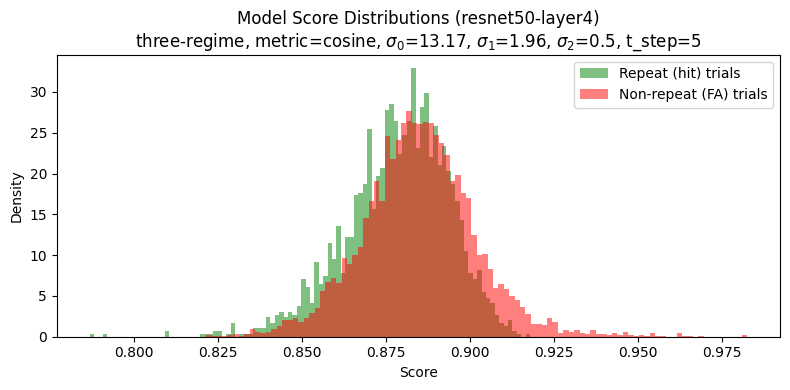

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(all_repeat_scores, bins=100, color='g', alpha=0.5, label="Repeat (hit) trials", density=True)
ax.hist(all_non_repeat_scores, bins=100, color='r', alpha=0.5, label="Non-repeat (FA) trials", density=True)
ax.set_xlabel("Score")
ax.set_ylabel("Density")
ax.set_title(
    f"Model Score Distributions ({params['encoder']}-{params['layer']})\n"
    f"{params['noise_mode']}, metric={params['metric']}, "
    f"$\\sigma_0$={params['sigma0']}, $\\sigma_1$={params['sigma1']}, "
    f"$\\sigma_2$={params['sigma2']}, t_step={params['t_step']}"
)
ax.legend()
plt.tight_layout()
plt.show()

## 5. ROC Analysis & Optimal Threshold

Find the threshold at which the model's false alarm rate matches the average human false alarm rate.

In [11]:
# ── model ROC ──
fpr_m, tpr_m, thresholds_m = roc_from_arrays_with_threshold(
    all_repeat_scores, all_non_repeat_scores, score_type=score_type
)

# ── human ROC (from binary responses) ──
repeat_scores_humans     = 1 - np.array(all_human_hit_responses)
non_repeat_scores_humans = 1 - np.array(all_human_fa_responses)
fpr_h, tpr_h, thresholds_h = roc_from_arrays_with_threshold(
    repeat_scores_humans, non_repeat_scores_humans
)

# human operating point (threshold = 1 in the flipped space)
thres_index_h = np.where(thresholds_h == 1)[0]
if len(thres_index_h) > 0:
    thres_index_h = thres_index_h[0]
    human_fpr_at_threshold = fpr_h[thres_index_h]
    human_tpr_at_threshold = tpr_h[thres_index_h]
else:
    # fallback: use the overall rates directly
    human_fpr_at_threshold = human_overall_far
    human_tpr_at_threshold = human_overall_hr

print(f"Human operating point: FAR={human_fpr_at_threshold:.3f}, HR={human_tpr_at_threshold:.3f}")

# ── find model threshold matching human FAR ──
threshold_roc, matched_fpr, matched_tpr = threshold_for_target_fa(
    fpr_m, tpr_m, thresholds_m, human_fpr_at_threshold
)

# convert from ROC space back to score space
threshold = -threshold_roc  # roc_from_arrays_with_threshold negates distance scores

print(f"\nModel threshold (matching human FAR):")
print(f"  Threshold (score space): {threshold:.4f}")
print(f"  Model FAR at threshold:  {matched_fpr:.3f}")
print(f"  Model HR  at threshold:  {matched_tpr:.3f}")

Human operating point: FAR=0.197, HR=0.855

Model threshold (matching human FAR):
  Threshold (score space): 0.8716
  Model FAR at threshold:  0.197
  Model HR  at threshold:  0.299


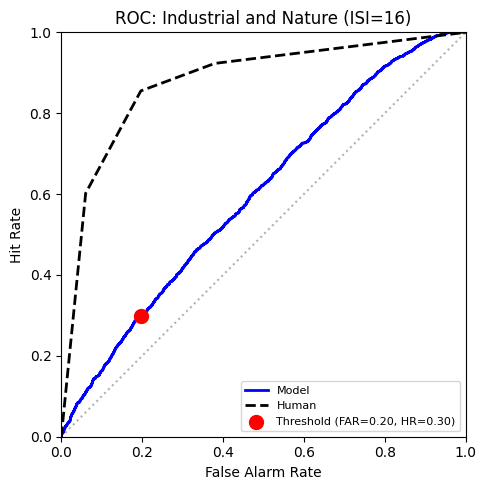

In [12]:
# ── plot ROC curves ──
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr_m, tpr_m, 'b-', lw=2, label="Model")
ax.plot(fpr_h, tpr_h, 'k--', lw=2, label="Human")
ax.scatter([matched_fpr], [matched_tpr], color='r', s=100, zorder=5,
           label=f"Threshold (FAR={matched_fpr:.2f}, HR={matched_tpr:.2f})")
# if len(thres_index_h) > 0:
#     ax.scatter([human_fpr_at_threshold], [human_tpr_at_threshold],
#               color='k', marker='x', s=100, zorder=5, label="Human operating pt")
ax.plot([0, 1], [0, 1], 'k:', alpha=0.3)
ax.set_xlabel("False Alarm Rate")
ax.set_ylabel("Hit Rate")
ax.set_title(f"ROC: {hr_task_name} (ISI={which_isi})")
ax.legend(fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 6. Compute Model Itemwise HR & FAR

In [13]:
item_hr_model, item_far_model = compute_itemwise_hit_fa_rates(
    all_item_hits,
    all_item_fas,
    threshold,
    score_type=score_type,
)

# summary
model_hrs  = [v for v in item_hr_model.values()  if not np.isnan(v)]
model_fars = [v for v in item_far_model.values() if not np.isnan(v)]

print(f"Model itemwise HR:  mean={np.mean(model_hrs):.3f}, "
      f"std={np.std(model_hrs):.3f}, N={len(model_hrs)}")
print(f"Model itemwise FAR: mean={np.mean(model_fars):.3f}, "
      f"std={np.std(model_fars):.3f}, N={len(model_fars)}")

# human summary for comparison
human_hrs  = [v for v in item_hr_human.values()  if not np.isnan(v)]
human_fars = [v for v in item_far_human.values() if not np.isnan(v)]

print(f"\nHuman itemwise HR:  mean={np.mean(human_hrs):.3f}, "
      f"std={np.std(human_hrs):.3f}, N={len(human_hrs)}")
print(f"Human itemwise FAR: mean={np.mean(human_fars):.3f}, "
      f"std={np.std(human_fars):.3f}, N={len(human_fars)}")

Model itemwise HR:  mean=0.298, std=0.176, N=80
Model itemwise FAR: mean=0.196, std=0.121, N=80

Human itemwise HR:  mean=0.855, std=0.108, N=80
Human itemwise FAR: mean=0.197, std=0.123, N=80


## 7. Correlation Analysis: Hit Rates (Human vs Model)

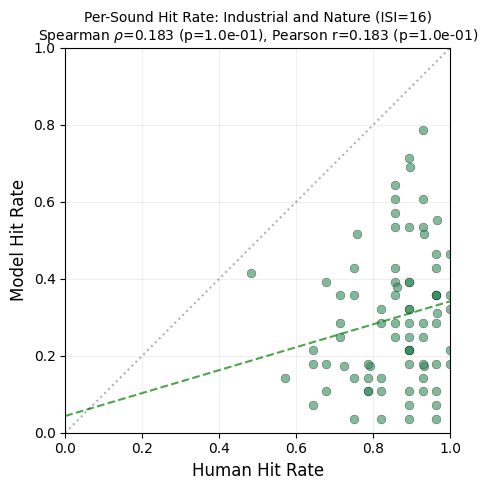

N sounds: 80
Spearman rho=0.183, p=0.1048
Pearson  r=0.183,   p=0.1037


In [14]:
rho_hr, p_hr, x_hr, y_hr, items_hr = correlate_itemwise_rates(
    item_hr_human, item_hr_model, method="spearman", return_vectors=True
)
r_hr, p_hr_pearson = pearsonr(x_hr, y_hr)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x_hr, y_hr, alpha=0.6, color='seagreen', edgecolors='k', linewidths=0.3, s=40)

# regression line
m, b = np.polyfit(x_hr, y_hr, 1)
x_fit = np.linspace(0, 1, 100)
ax.plot(x_fit, m * x_fit + b, 'g--', lw=1.5, alpha=0.7)

ax.plot([0, 1], [0, 1], 'k:', alpha=0.3, label="identity")
ax.set_xlabel("Human Hit Rate", fontsize=12)
ax.set_ylabel("Model Hit Rate", fontsize=12)
ax.set_title(
    f"Per-Sound Hit Rate: {hr_task_name} (ISI={which_isi})\n"
    f"Spearman $\\rho$={rho_hr:.3f} (p={p_hr:.1e}), "
    f"Pearson r={r_hr:.3f} (p={p_hr_pearson:.1e})",
    fontsize=10,
)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f"N sounds: {len(items_hr)}")
print(f"Spearman rho={rho_hr:.3f}, p={p_hr:.4f}")
print(f"Pearson  r={r_hr:.3f},   p={p_hr_pearson:.4f}")

## 8. Correlation Analysis: False Alarm Rates (Human vs Model)

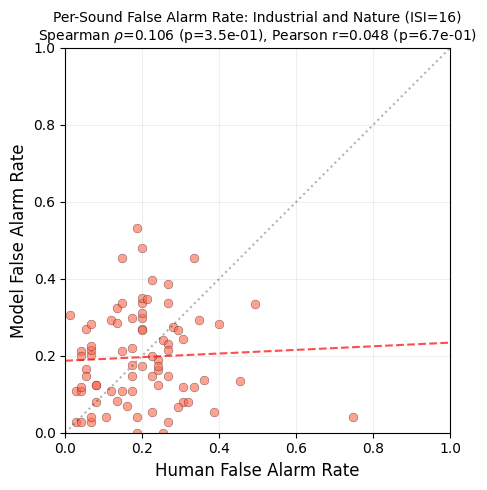

N sounds: 80
Spearman rho=0.106, p=0.3516
Pearson  r=0.048,   p=0.6746


In [15]:
rho_far, p_far, x_far, y_far, items_far = correlate_itemwise_rates(
    item_far_human, item_far_model, method="spearman", return_vectors=True
)
r_far, p_far_pearson = pearsonr(x_far, y_far)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x_far, y_far, alpha=0.6, color='tomato', edgecolors='k', linewidths=0.3, s=40)

# regression line
m, b = np.polyfit(x_far, y_far, 1)
x_fit = np.linspace(0, 1, 100)
ax.plot(x_fit, m * x_fit + b, 'r--', lw=1.5, alpha=0.7)

ax.plot([0, 1], [0, 1], 'k:', alpha=0.3, label="identity")
ax.set_xlabel("Human False Alarm Rate", fontsize=12)
ax.set_ylabel("Model False Alarm Rate", fontsize=12)
ax.set_title(
    f"Per-Sound False Alarm Rate: {hr_task_name} (ISI={which_isi})\n"
    f"Spearman $\\rho$={rho_far:.3f} (p={p_far:.1e}), "
    f"Pearson r={r_far:.3f} (p={p_far_pearson:.1e})",
    fontsize=10,
)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f"N sounds: {len(items_far)}")
print(f"Spearman rho={rho_far:.3f}, p={p_far:.4f}")
print(f"Pearson  r={r_far:.3f},   p={p_far_pearson:.4f}")

## 9. Bar Plots: Sounds Ranked by Hit Rate

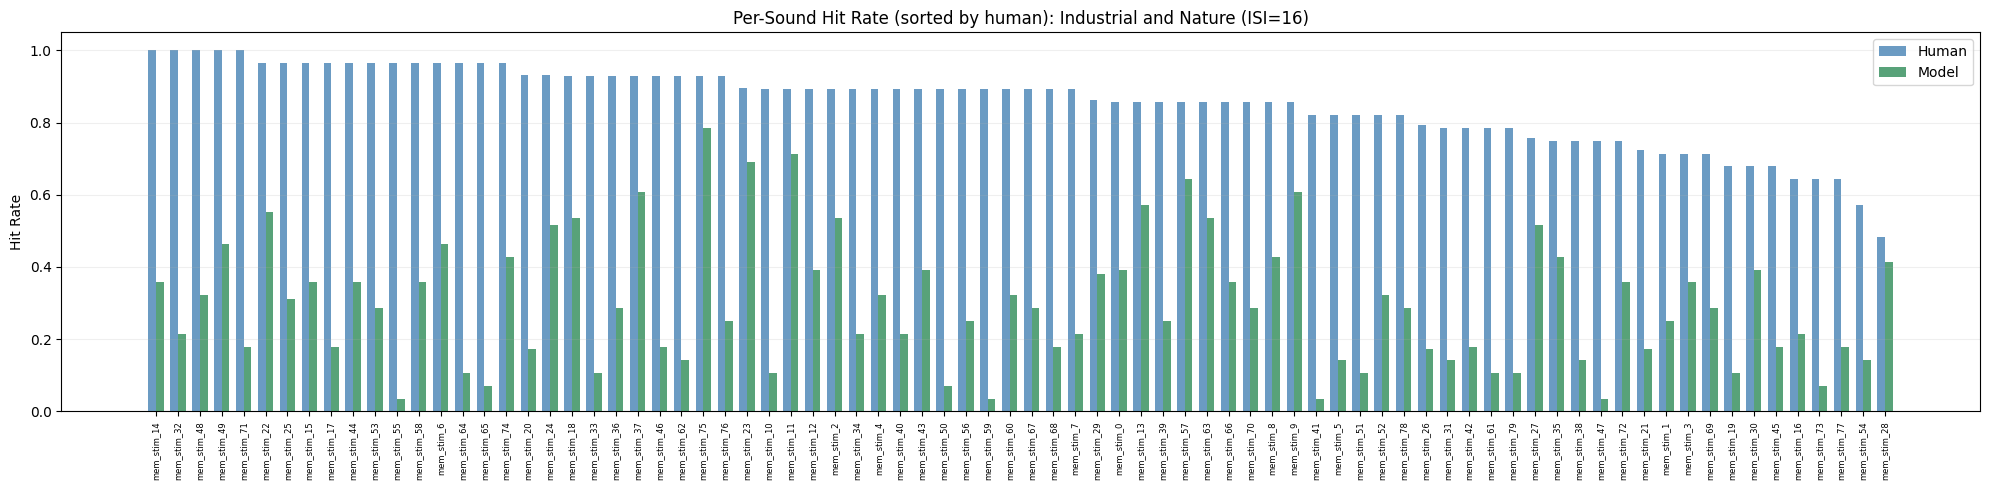

In [16]:
# ── align and sort by human HR ──
common_hr = sorted(set(item_hr_human) & set(item_hr_model))
common_hr = [s for s in common_hr
             if not np.isnan(item_hr_human.get(s, np.nan))
             and not np.isnan(item_hr_model.get(s, np.nan))]

common_hr = sorted(common_hr, key=lambda s: item_hr_human[s], reverse=True)

h_hrs = [item_hr_human[s] for s in common_hr]
m_hrs = [item_hr_model[s] for s in common_hr]
short_names = [s.replace(".wav", "")[-20:] for s in common_hr]

n_items = len(common_hr)
x = np.arange(n_items)
w = 0.35

fig, ax = plt.subplots(figsize=(max(12, n_items * 0.25), 5))
ax.bar(x - w/2, h_hrs, w, color='steelblue', alpha=0.8, label='Human')
ax.bar(x + w/2, m_hrs, w, color='seagreen',  alpha=0.8, label='Model')
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=90, fontsize=6)
ax.set_ylabel("Hit Rate")
ax.set_title(f"Per-Sound Hit Rate (sorted by human): {hr_task_name} (ISI={which_isi})")
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

## 10. Bar Plots: Sounds Ranked by False Alarm Rate

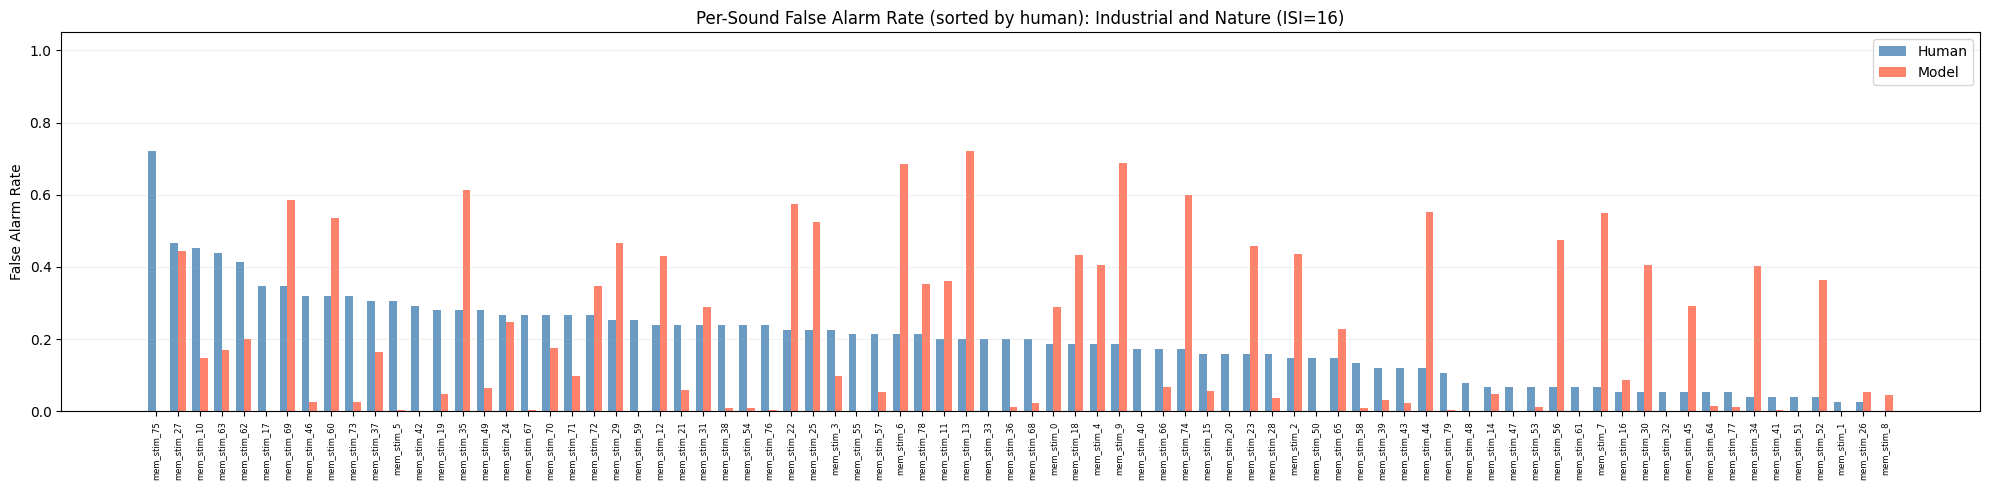

In [41]:
# ── align and sort by human FAR ──
common_far = sorted(set(item_far_human) & set(item_far_model))
common_far = [s for s in common_far
              if not np.isnan(item_far_human.get(s, np.nan))
              and not np.isnan(item_far_model.get(s, np.nan))]

common_far = sorted(common_far, key=lambda s: item_far_human[s], reverse=True)

h_fars = [item_far_human[s] for s in common_far]
m_fars = [item_far_model[s] for s in common_far]
short_names_far = [s.replace(".wav", "")[-20:] for s in common_far]

n_items_far = len(common_far)
x = np.arange(n_items_far)
w = 0.35

fig, ax = plt.subplots(figsize=(max(12, n_items_far * 0.25), 5))
ax.bar(x - w/2, h_fars, w, color='steelblue', alpha=0.8, label='Human')
ax.bar(x + w/2, m_fars, w, color='tomato',    alpha=0.8, label='Model')
ax.set_xticks(x)
ax.set_xticklabels(short_names_far, rotation=90, fontsize=6)
ax.set_ylabel("False Alarm Rate")
ax.set_title(f"Per-Sound False Alarm Rate (sorted by human): {hr_task_name} (ISI={which_isi})")
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

## 11. Combined Summary Figure (2x2)

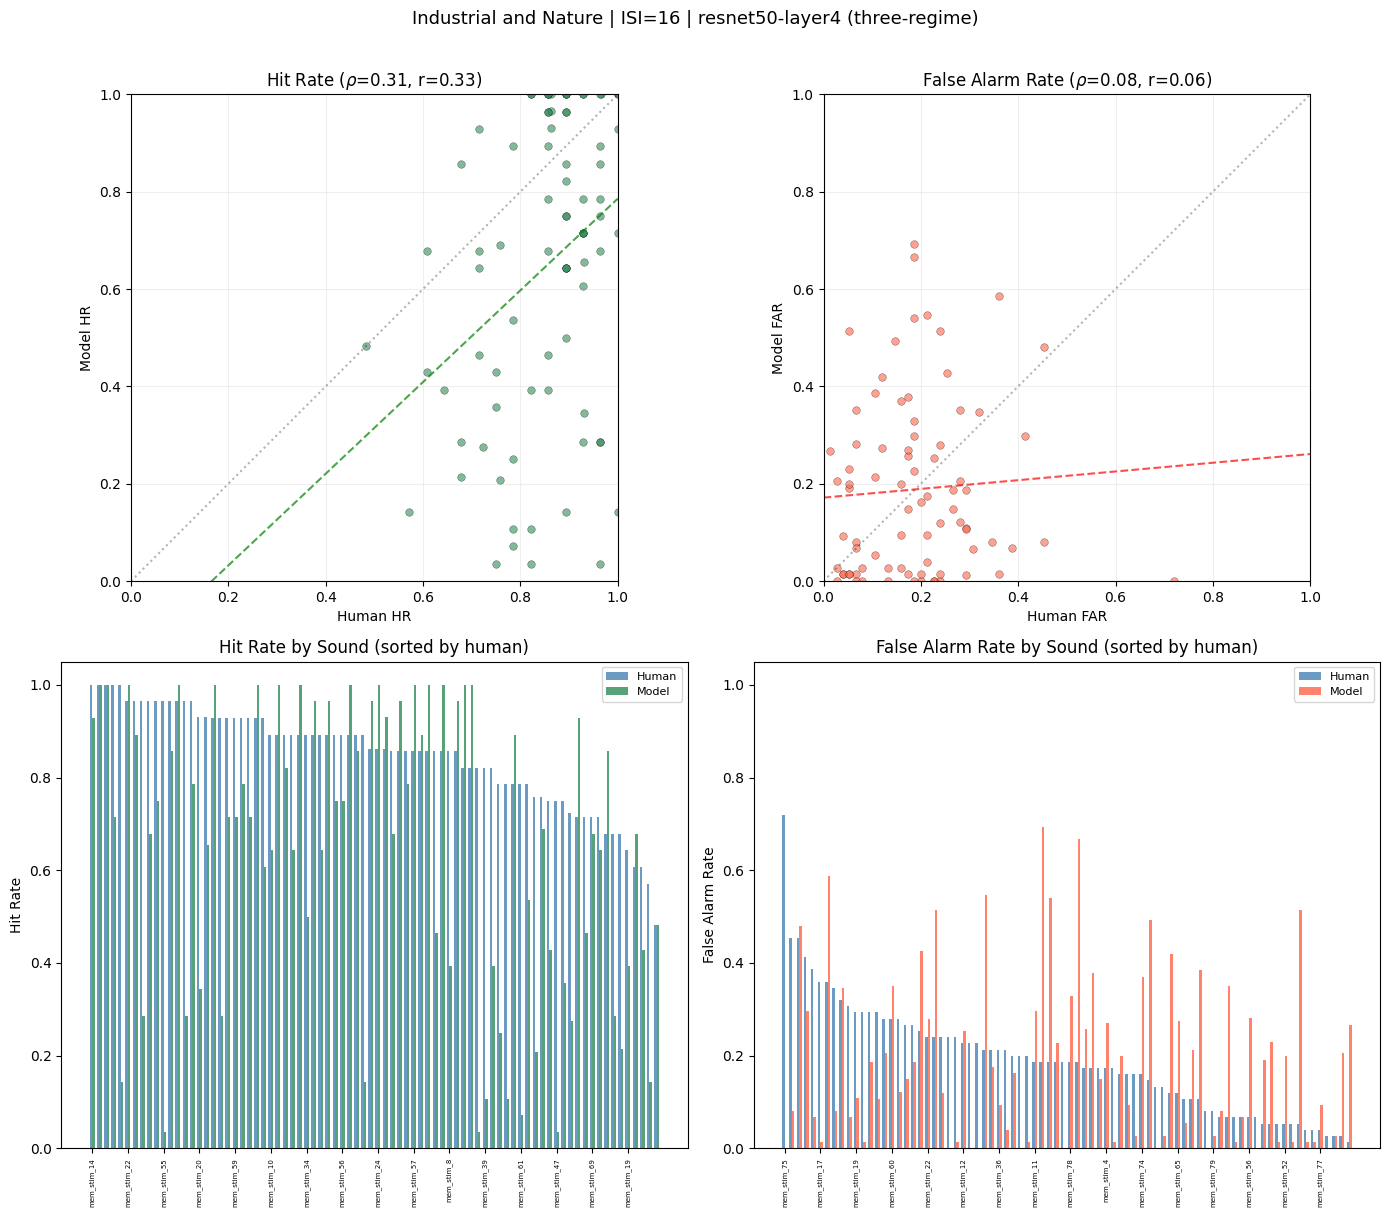

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# ── (0,0) HR scatter ──
ax = axes[0, 0]
ax.scatter(x_hr, y_hr, alpha=0.6, color='seagreen', edgecolors='k', linewidths=0.3, s=30)
m_fit, b_fit = np.polyfit(x_hr, y_hr, 1)
xf = np.linspace(0, 1, 100)
ax.plot(xf, m_fit * xf + b_fit, 'g--', lw=1.5, alpha=0.7)
ax.plot([0, 1], [0, 1], 'k:', alpha=0.3)
ax.set_xlabel("Human HR")
ax.set_ylabel("Model HR")
ax.set_title(f"Hit Rate ($\\rho$={rho_hr:.2f}, r={r_hr:.2f})")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.grid(True, alpha=0.2)

# ── (0,1) FAR scatter ──
ax = axes[0, 1]
ax.scatter(x_far, y_far, alpha=0.6, color='tomato', edgecolors='k', linewidths=0.3, s=30)
m_fit, b_fit = np.polyfit(x_far, y_far, 1)
ax.plot(xf, m_fit * xf + b_fit, 'r--', lw=1.5, alpha=0.7)
ax.plot([0, 1], [0, 1], 'k:', alpha=0.3)
ax.set_xlabel("Human FAR")
ax.set_ylabel("Model FAR")
ax.set_title(f"False Alarm Rate ($\\rho$={rho_far:.2f}, r={r_far:.2f})")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.grid(True, alpha=0.2)

# ── (1,0) HR bar plot ──
ax = axes[1, 0]
n = len(common_hr)
xi = np.arange(n)
ax.bar(xi - 0.175, h_hrs, 0.35, color='steelblue', alpha=0.8, label='Human')
ax.bar(xi + 0.175, m_hrs, 0.35, color='seagreen',  alpha=0.8, label='Model')
ax.set_xticks(xi[::max(1, n//15)])
ax.set_xticklabels([short_names[i] for i in range(0, n, max(1, n//15))],
                    rotation=90, fontsize=5)
ax.set_ylabel("Hit Rate")
ax.set_title("Hit Rate by Sound (sorted by human)")
ax.legend(fontsize=8)
ax.set_ylim(0, 1.05)

# ── (1,1) FAR bar plot ──
ax = axes[1, 1]
nf = len(common_far)
xi = np.arange(nf)
ax.bar(xi - 0.175, h_fars, 0.35, color='steelblue', alpha=0.8, label='Human')
ax.bar(xi + 0.175, m_fars, 0.35, color='tomato',    alpha=0.8, label='Model')
ax.set_xticks(xi[::max(1, nf//15)])
ax.set_xticklabels([short_names_far[i] for i in range(0, nf, max(1, nf//15))],
                    rotation=90, fontsize=5)
ax.set_ylabel("False Alarm Rate")
ax.set_title("False Alarm Rate by Sound (sorted by human)")
ax.legend(fontsize=8)
ax.set_ylim(0, 1.05)

fig.suptitle(
    f"{hr_task_name} | ISI={which_isi} | {params['encoder']}-{params['layer']} "
    f"({params['noise_mode']})",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

## 12. Per-Sound Threshold Analysis

Instead of one global threshold, find a **per-sound** threshold that matches
each sound's human FAR individually. Then compute the per-sound HR at that
individually-calibrated threshold and correlate with human HR.

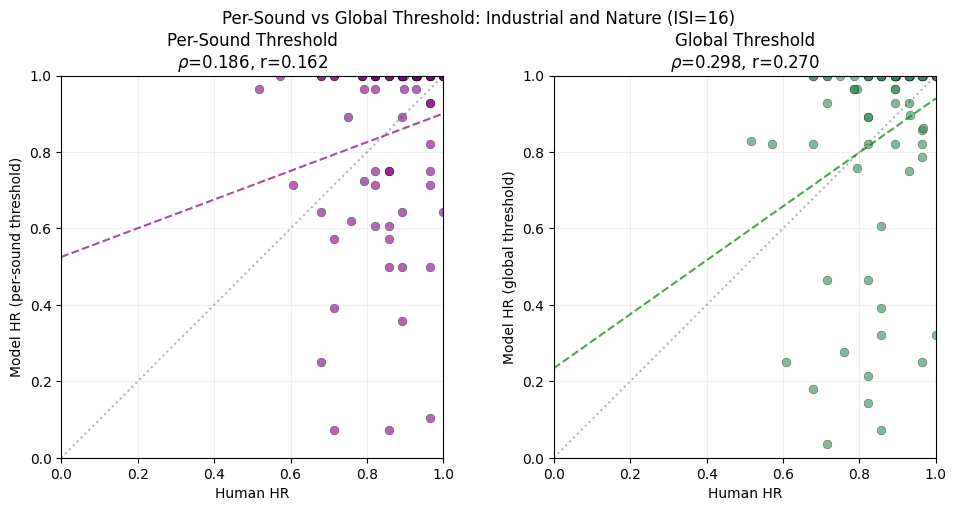

Per-sound threshold: Spearman rho=0.186 (p=0.0987), Pearson r=0.162 (p=0.1503)
Global threshold:    Spearman rho=0.298 (p=0.0072), Pearson r=0.270 (p=0.0154)


In [29]:
item_hr_persound_thresh = {}
item_far_persound_thresh = {}

for stim in common_hr:
    stim_key_hits = None
    stim_key_fas  = None

    # find matching keys in model dicts (may include full path)
    for k in all_item_fas:
        if k.split("/")[-1] == stim:
            stim_key_fas = k
            break
    for k in all_item_hits:
        if k.split("/")[-1] == stim:
            stim_key_hits = k
            break

    if stim_key_fas is None or len(all_item_fas[stim_key_fas]) < 2:
        continue

    target_far = item_far_human.get(stim, np.nan)
    if np.isnan(target_far):
        continue

    # get model FA scores for this sound
    fa_scores_stim = np.array(all_item_fas[stim_key_fas])

    # find threshold that gives target FAR for this sound
    if score_type == "distance":
        sorted_scores = np.sort(fa_scores_stim)
        idx = max(0, int(np.round(target_far * len(sorted_scores))) - 1)
        per_sound_threshold = sorted_scores[idx]
    else:
        sorted_scores = np.sort(fa_scores_stim)[::-1]
        idx = max(0, int(np.round(target_far * len(sorted_scores))) - 1)
        per_sound_threshold = sorted_scores[idx]

    # compute FAR at this threshold
    yes_fa = apply_threshold(fa_scores_stim, per_sound_threshold, score_type)
    item_far_persound_thresh[stim] = np.mean(yes_fa)

    # compute HR at this threshold
    if stim_key_hits is not None and len(all_item_hits[stim_key_hits]) > 0:
        hit_scores_stim = np.array(all_item_hits[stim_key_hits])
        yes_hit = apply_threshold(hit_scores_stim, per_sound_threshold, score_type)
        item_hr_persound_thresh[stim] = np.mean(yes_hit)

# correlate per-sound threshold HR with human HR
if len(item_hr_persound_thresh) >= 3:
    rho_ps, p_ps, x_ps, y_ps, items_ps = correlate_itemwise_rates(
        item_hr_human, item_hr_persound_thresh,
        method="spearman", return_vectors=True,
    )
    r_ps, p_ps_pearson = pearsonr(x_ps, y_ps)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    # per-sound threshold
    ax1.scatter(x_ps, y_ps, alpha=0.6, color='purple', edgecolors='k', linewidths=0.3, s=40)
    m_fit, b_fit = np.polyfit(x_ps, y_ps, 1)
    xf = np.linspace(0, 1, 100)
    ax1.plot(xf, m_fit * xf + b_fit, '--', color='purple', lw=1.5, alpha=0.7)
    ax1.plot([0, 1], [0, 1], 'k:', alpha=0.3)
    ax1.set_xlabel("Human HR")
    ax1.set_ylabel("Model HR (per-sound threshold)")
    ax1.set_title(f"Per-Sound Threshold\n$\\rho$={rho_ps:.3f}, r={r_ps:.3f}")
    ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)
    ax1.set_aspect("equal")
    ax1.grid(True, alpha=0.2)

    # global threshold for comparison
    ax2.scatter(x_hr, y_hr, alpha=0.6, color='seagreen', edgecolors='k', linewidths=0.3, s=40)
    m_fit, b_fit = np.polyfit(x_hr, y_hr, 1)
    ax2.plot(xf, m_fit * xf + b_fit, 'g--', lw=1.5, alpha=0.7)
    ax2.plot([0, 1], [0, 1], 'k:', alpha=0.3)
    ax2.set_xlabel("Human HR")
    ax2.set_ylabel("Model HR (global threshold)")
    ax2.set_title(f"Global Threshold\n$\\rho$={rho_hr:.3f}, r={r_hr:.3f}")
    ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
    ax2.set_aspect("equal")
    ax2.grid(True, alpha=0.2)

    fig.suptitle(f"Per-Sound vs Global Threshold: {hr_task_name} (ISI={which_isi})", fontsize=12)
    plt.tight_layout()
    plt.show()

    print(f"Per-sound threshold: Spearman rho={rho_ps:.3f} (p={p_ps:.4f}), "
          f"Pearson r={r_ps:.3f} (p={p_ps_pearson:.4f})")
    print(f"Global threshold:    Spearman rho={rho_hr:.3f} (p={p_hr:.4f}), "
          f"Pearson r={r_hr:.3f} (p={p_hr_pearson:.4f})")
else:
    print("Not enough overlapping sounds for per-sound threshold analysis.")

## 13. Per-Sound d' Analysis

Compute item-level d' for both humans and the model, then correlate.

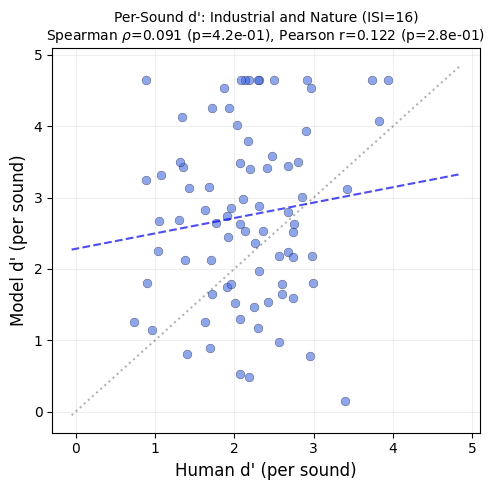

N sounds: 80
Spearman rho=0.091, p=0.4236
Pearson  r=0.122,   p=0.2800


In [30]:
def dprime_from_rates(hit_rate, fa_rate, eps=1e-2):
    """Compute d' from hit and false-alarm rates."""
    hr = np.clip(hit_rate, eps, 1 - eps)
    fr = np.clip(fa_rate, eps, 1 - eps)
    return norm.ppf(hr) - norm.ppf(fr)


# ── compute per-sound d' for humans ──
item_dp_human = {}
for stim in set(item_hr_human) & set(item_far_human):
    hr_val = item_hr_human.get(stim, np.nan)
    fr_val = item_far_human.get(stim, np.nan)
    if not np.isnan(hr_val) and not np.isnan(fr_val):
        item_dp_human[stim] = dprime_from_rates(hr_val, fr_val)

# ── compute per-sound d' for model (global threshold) ──
item_dp_model = {}
for stim in set(item_hr_model) & set(item_far_model):
    hr_val = item_hr_model.get(stim, np.nan)
    fr_val = item_far_model.get(stim, np.nan)
    if not np.isnan(hr_val) and not np.isnan(fr_val):
        item_dp_model[stim] = dprime_from_rates(hr_val, fr_val)

# ── correlate ──
if len(set(item_dp_human) & set(item_dp_model)) >= 3:
    rho_dp, p_dp, x_dp, y_dp, items_dp = correlate_itemwise_rates(
        item_dp_human, item_dp_model,
        method="spearman", return_vectors=True,
    )
    r_dp, p_dp_pearson = pearsonr(x_dp, y_dp)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(x_dp, y_dp, alpha=0.6, color='royalblue', edgecolors='k', linewidths=0.3, s=40)

    m_fit, b_fit = np.polyfit(x_dp, y_dp, 1)
    dp_range = np.linspace(min(x_dp.min(), y_dp.min()) - 0.2,
                           max(x_dp.max(), y_dp.max()) + 0.2, 100)
    ax.plot(dp_range, m_fit * dp_range + b_fit, 'b--', lw=1.5, alpha=0.7)
    ax.plot(dp_range, dp_range, 'k:', alpha=0.3)

    ax.set_xlabel("Human d' (per sound)", fontsize=12)
    ax.set_ylabel("Model d' (per sound)", fontsize=12)
    ax.set_title(
        f"Per-Sound d': {hr_task_name} (ISI={which_isi})\n"
        f"Spearman $\\rho$={rho_dp:.3f} (p={p_dp:.1e}), "
        f"Pearson r={r_dp:.3f} (p={p_dp_pearson:.1e})",
        fontsize=10,
    )
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    print(f"N sounds: {len(items_dp)}")
    print(f"Spearman rho={rho_dp:.3f}, p={p_dp:.4f}")
    print(f"Pearson  r={r_dp:.3f},   p={p_dp_pearson:.4f}")
else:
    print("Not enough overlapping sounds for per-sound d' analysis.")

## 14. Summary Statistics Table

In [ ]:
# ── build a comprehensive per-sound table ──
all_sounds = sorted(
    set(item_hr_human) | set(item_far_human)
    | set(item_hr_model) | set(item_far_model)
)

rows = []
for stim in all_sounds:
    rows.append({
        "sound":      stim.replace(".wav", ""),
        "human_hr":   item_hr_human.get(stim, np.nan),
        "model_hr":   item_hr_model.get(stim, np.nan),
        "human_far":  item_far_human.get(stim, np.nan),
        "model_far":  item_far_model.get(stim, np.nan),
        "human_dp":   item_dp_human.get(stim, np.nan),
        "model_dp":   item_dp_model.get(stim, np.nan),
    })

df_summary = pd.DataFrame(rows).sort_values("human_hr", ascending=False).reset_index(drop=True)

print(f"\n{'='*80}")
print(f"SUMMARY: {hr_task_name} | ISI={which_isi}")
print(f"Model: {params['encoder']}-{params['layer']} ({params['noise_mode']})")
print(f"  sigma0={params['sigma0']}, sigma1={params['sigma1']}, "
      f"sigma2={params['sigma2']}, t_step={params['t_step']}")
print(f"  threshold={threshold:.4f}, n_runs={n_runs}")
print(f"{'='*80}")
print(f"\nCorrelations:")
print(f"  Hit Rate:        Spearman rho={rho_hr:.3f}  (p={p_hr:.4f})")
print(f"  False Alarm Rate: Spearman rho={rho_far:.3f} (p={p_far:.4f})")
if 'rho_dp' in dir():
    print(f"  d' (per sound):  Spearman rho={rho_dp:.3f} (p={p_dp:.4f})")
print(f"\nMean Rates:")
print(f"  Human HR={human_overall_hr:.3f}, Model HR={matched_tpr:.3f}")
print(f"  Human FAR={human_overall_far:.3f}, Model FAR={matched_fpr:.3f}")
print(f"\n")
df_summary.round(3)